# Example usage for the qsp_rs python module

### Setup
First, you need to install the rust toolchain. See https://rust-lang.org/tools/install/ for more.
Then, create a new venv and install maturin there:
```bash
# This assumes you are in the repository root. If not, update the paths accordingly.
python -m venv .venv # or choose a different location
source ./.venv/bin/activate # for unix, windows might differ
pip install maturin
```
then build the python module:
```bash
cd crates/python
maturin develop --release
```
this will build the project and add it to the venv you are currently working in. From then, just make sure that when you try and run the module you are also in that venv (for jupyter notebooks such as this file: choose the correct kernel).

In [1]:
import numpy as np
import qsp_rs as qsp

# Solve for phases
result = qsp.solve_poly_with_pattern(
    target_half_len=10,
    target_pattern="rand",
    parity="even",
    solver="bfgs",
    phase_map="none",
    bfgs_options={
        "max_iters": 500000
    },
    seed=1,
    mode="s,60",
    regularize=1e-6,
)
result


SolveResult(cost=1.606e-6, n_phases=61, total_phase=7.611728110695735, iterations=94477, termination='converged', elapsed_ms=2875.9)

In [2]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

class TqdmProgress:
    def __init__(self):
        self.bar = None

    def __call__(self, p):
        if p["new_stage"]:
            self._close_bar()
            self.bar = tqdm(
                desc=f"stage {p['stage_index']+1}/{p['stage_total']} (deg={p['stage_degree']})",
                bar_format="{desc}: {n_fmt} iters [{elapsed}{postfix}]",
                leave=True,
            )
        if self.bar is not None:
            self.bar.n = p["iter"]
            self.bar.set_postfix_str(f"cost={p['cost']:.3e}", refresh=False)
            self.bar.refresh()

    def _close_bar(self):
        if self.bar is not None:
            self.bar.close()
            self.bar = None

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self._close_bar()
        return False


def create_plt_x(f, res, title=None, only_on_target=False):
    sol_phis = res.phases
    x_samples = res.target.xs
    y_full = res.target.ys
    
    ax = f.gca()
    xs = np.array(sorted(x_samples)) if only_on_target else np.linspace(-1, 1, 30*len(x_samples))
    poly = qsp.evaluate_poly(sol_phis, xs)
    
    ax.plot(xs, poly.real, label="Re[P(x)]")
    ax.plot(xs, poly.imag, label="Im[P(x)]")
    ax.scatter(x_samples, y_full.real, label="Re[y_target]")
    ax.scatter(x_samples, y_full.imag, label="Im[y_target]", marker="x")
    if title:
        f.title(title)
    ax.legend()
    return f

def create_plt_k(f, res, title=None, only_on_target=False):
    sol_phis = res.phases
    y_full = res.target.ys
    ax = f.gca()
    N_half = len(y_full) // 2
    if only_on_target:
        ks = np.arange(1, N_half+1)
        thetas = np.array([qsp.theta_k_continuous(k, N_half) for k in ks])
        poly = qsp.evaluate_poly(sol_phis, np.cos(thetas))
        ax.plot(ks, poly.real, label="Re[P(cos(θ_k))]", c="lightgreen", ls="--", marker="D", ms=4, zorder=30)
        ax.plot(ks, poly.imag, label="Im[P(cos(θ_k))]", c="red", ls="--", marker="D", ms=4, zorder=30)
    else:
        ks = np.linspace(1, N_half, 30*N_half)
        thetas = np.array([qsp.theta_k_continuous(k, N_half) for k in ks])
        poly = qsp.evaluate_poly(sol_phis, np.cos(thetas))
        ax.plot(ks, poly.real, label="Re[P(cos(θ_k))]", c="lightgreen", ls="--", zorder=30)
        ax.plot(ks, poly.imag, label="Im[P(cos(θ_k))]", c="red", ls="--", zorder=30)

        # markers
        ks_m = np.arange(1,N_half+1)
        thetas_m = np.array([qsp.theta_k(k, N_half) for k in ks_m])
        poly_m = qsp.evaluate_poly(sol_phis, np.cos(thetas_m))
        ax.scatter(ks_m, poly_m.real, c="lightgreen", marker="D", s=16, zorder=30)
        ax.scatter(ks_m, poly_m.imag, c="red", marker="D", s=16, zorder=30)

    
    ax.set_xlabel("k")
    if title:
        f.title(title)
    ax.scatter(np.arange(1, N_half+1), y_full.real[N_half:], label="Re[y_target]", c="blue", zorder=15)
    ax.scatter(np.arange(1, N_half+1), y_full.imag[N_half:], label="Im[y_target]", marker="x", c="orange", zorder=15)
    ax.legend()
    return f


def pp_sq_err(res, print_all=False):
    phis = res.phases
    x_samples = res.target.xs
    y_full = res.target.ys
    p_at_samples = qsp.evaluate_poly(phis, x_samples)
    ppe = []
    for i in np.argsort(x_samples):
        err2 = (p_at_samples[i].real - y_full[i].real)**2 + p_at_samples[i].imag**2
        if print_all:
            print(f"  x={x_samples[i]:+.3f}  target={y_full[i].real:.0f}  P_re={p_at_samples[i].real:+.4f}  err²={err2:.4f}")
        ppe.append(err2)
        
    return np.sqrt(np.max(ppe))

def full_eval(res, title=None, only_on_target = False):
    print(f"Max. square pointwise error: {pp_sq_err(res)}")
    create_plt_x(plt, res, title, only_on_target).show()
    create_plt_k(plt, res, title, only_on_target).show()

/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Max. square pointwise error: 1.0823965508574988e-05


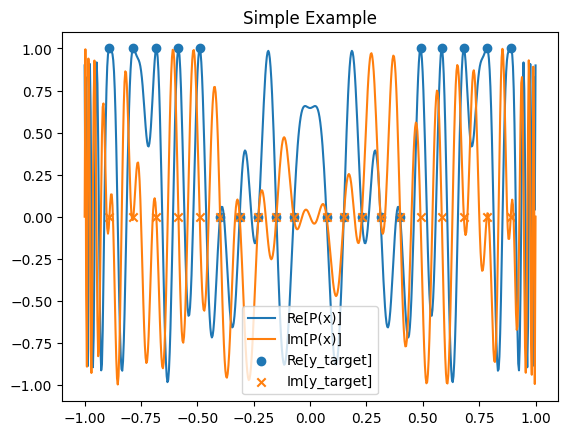

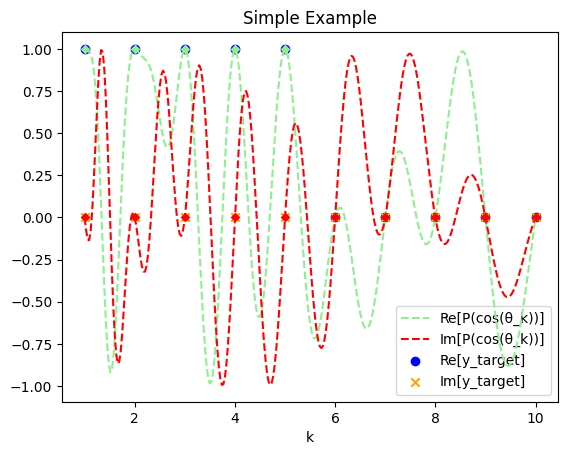

In [3]:
full_eval(result, "Simple Example")

In [4]:
with TqdmProgress() as prog:
    result_large = qsp.solve_poly_with_pattern(target_half_len=400,
        target_pattern="gp,16,0",
        parity="even",
        solver="bfgs",
        phase_map="mirror",
        init="0",
        mode="s,2500",
        progress=prog)

result_large

stage 1/1 (deg=2500): 587 iters [00:51, cost=5.378e-12]


SolveResult(cost=5.377e-12, n_phases=5001, total_phase=22.351329299210345, iterations=589, termination='converged', elapsed_ms=51941.1)

SolveResult(cost=5.377e-12, n_phases=5001, total_phase=22.351329299210345, iterations=589, termination='converged', elapsed_ms=51941.1)
5001
Max. square pointwise error: 8.204862169680638e-07


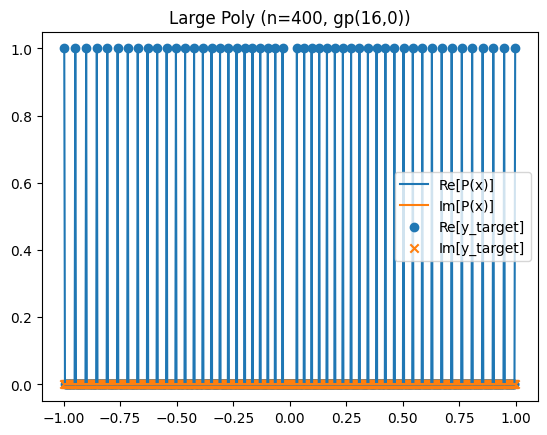

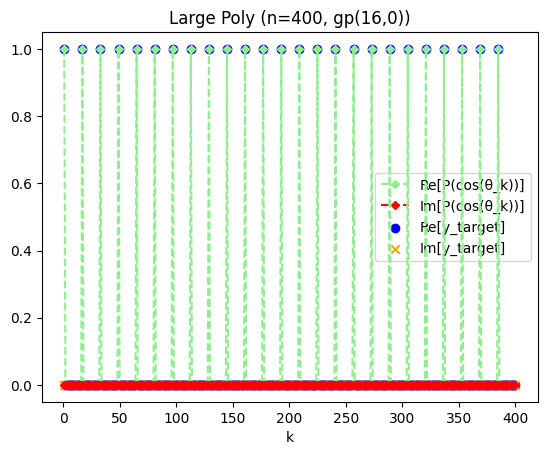

In [5]:
print(result_large)
print(len(result_large.phases))
full_eval(result_large, "Large Poly (n=400, gp(16,0))", only_on_target=True)

SolveResult(cost=1.604e-11, n_phases=121, total_phase=1519.8815945445033, iterations=9368, termination='converged', elapsed_ms=2550.7)
Max. square pointwise error: 1.4775135822597818e-06


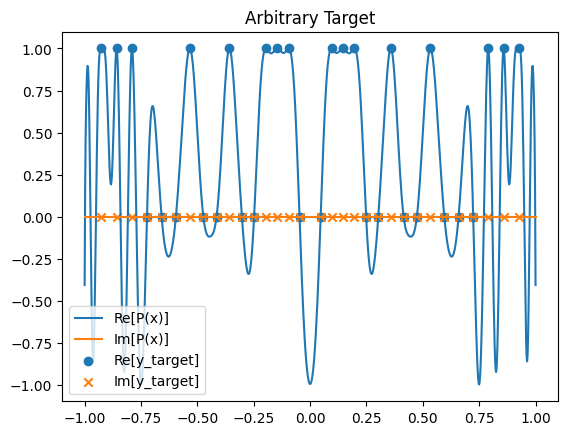

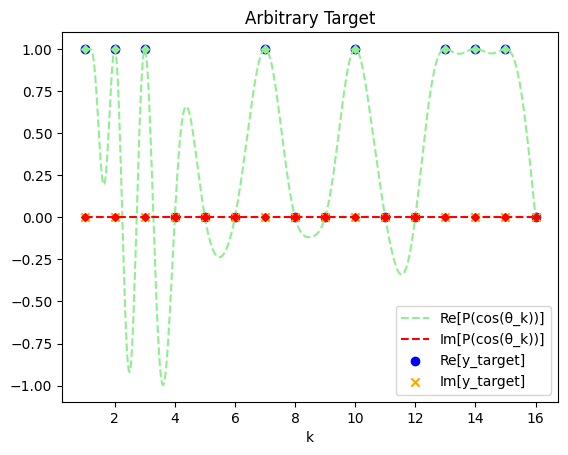

In [6]:
result = qsp.solve_poly([1,1,1,0,0,0,1,0,0,1,0,0,1,1,1,0], mode="h,20,60")
print(result)
full_eval(result, title="Arbitrary Target")

In [9]:
# test GP(13,0) from paper with equidistant points

with TqdmProgress() as prog:
    res = qsp.solve_poly(
        ([0] * 12 + [1])*5,
        target_dist="e",
        solver="lm",
        phase_map="mirror",
        init="0",
        mode="s,250",
        progress=prog
    )

stage 1/1 (deg=250): 73 iters [00:05, cost=3.334e-28]


SolveResult(cost=2.178e-28, n_phases=501, total_phase=4.977537755634987, iterations=78, termination='converged', elapsed_ms=5410.4)


/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/home/jay/Source/Bachelor Thesis/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


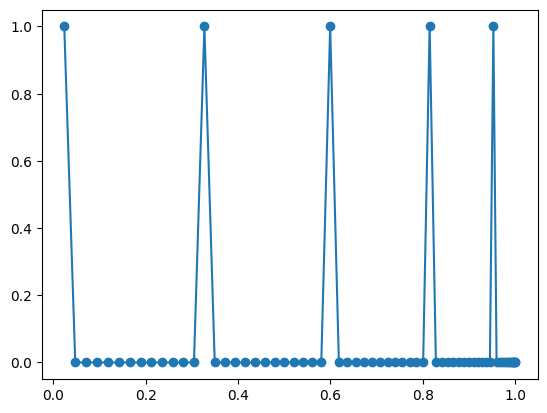

In [10]:
print(res)
n_half = len(res.target.ys) // 2
plt.scatter(res.target.xs[n_half:], res.target.ys[n_half:])
plt.plot(res.target.xs[n_half:], qsp.evaluate_poly(res.phases, res.target.xs[n_half:]))
plt.show()